In [1]:
!pip install google-generativeai tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import google.generativeai as genai

genai.configure(api_key="YOUR_API_HERE")
model = genai.GenerativeModel("gemini-2.5-flash")

try:
    response = model.generate_content("Hello Gemini!")
    print("✅ API key hoạt động bình thường!")
    print(response.text)
except Exception as e:
    print("❌ API key lỗi:", e)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


❌ API key lỗi: 400 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: API key not valid. Please pass a valid API key.


## Version 2.0

In [4]:
import json
import time
import os
from getpass import getpass
import google.generativeai as genai
from typing import Dict, Any

# --- CONFIGURATION ---
# Update these paths for your Colab Drive mount
INPUT_FILE = "/content/drive/MyDrive/LMMs/medreason_final_sft_dataset.json"
OUTPUT_REPORT_FILE = "/content/drive/MyDrive/LMMs/evaluate_medreason_finetune.json"

# --- API KEY HANDLING ---
# Prefer setting in Colab before running:
#   import os
#   os.environ["GEMINI_API_KEY"] = "your_key_here"
# If not set, you will be prompted securely.
api_key = os.environ.get("GEMINI_API_KEY") or getpass("Enter GEMINI_API_KEY: ")
if not api_key:
    raise ValueError("GEMINI_API_KEY is required.")

# --- FIDELITY PROMPT ---
FIDELITY_PROMPT = """
You are a senior medical editor reviewing a diagnostic teaching case derived from a historical medical source.

Your task is to assess whether the case is ACCEPTABLE for educational use.
This is a permissive, teaching-oriented fidelity review.

Your role is evaluative only.
Do NOT rewrite or correct the case.
ONLY flag clear violations.

=====================
INPUTS
=====================

1. SOURCE REPORT:
{source_json_content}

2. TEACHING CASE DRAFT:
- Vignette: "{question}"
- Final Diagnosis: "{answer}"
- Diagnostic Rationale: "{rationale}"

=====================
EVALUATION PRINCIPLES
=====================

This review prioritizes educational plausibility over strict textual fidelity.

The following are ACCEPTABLE and should NOT be flagged:
- Reasonable clinical inference not explicitly stated
- Typical laboratory patterns mentioned illustratively
- General epidemiological or pathophysiologic statements
- Implicit negatives (e.g., "no jaundice") if not contradicted
- Minor descriptive variation that does not alter diagnostic meaning
- Teaching-oriented explanations using general medical knowledge

=====================
FLAG ONLY IF
=====================

A case MUST be flagged only if it contains one or more of the following:

1. Direct contradiction of the source report
2. Biologically or epidemiologically impossible findings
3. Fabricated patient-specific facts that materially alter the diagnosis
4. Internal inconsistency (e.g., conflicting diagnoses)
5. Final diagnosis explicitly revealed in the vignette
6. Mutually exclusive or incompatible hallmark features combined

=====================
OUTPUT FORMAT (JSON ONLY)
=====================

Return a valid JSON object:

"flags":
- Use one or more of:
  - CASE_PROMPT_HALLUCINATION
  - DIAGNOSTIC_REASONING_HALLUCINATION
  - FINAL_DIAGNOSIS_IN_CASE_PROMPT
  - OTHER
- If no violations: ["NONE"]

"editorcomments":
- One concise sentence per flag
- Omit or leave empty if flags = ["NONE"]
"""

# --- QUALITY PROMPT ---
QUALITY_PROMPT = """
You are an expert medical educator tasked with evaluating a generated "Teaching Case" (Question/Answer pair) for its diagnostic-reasoning value.
Your goal is to ensure the case has the style and rigor of a diagnostic teaching case from a medical textbook.

### INPUTS TO EVALUATE
1. **CASE PRESENTATION (The Vignette):** "{question}"

2. **DIAGNOSTIC REASONING (The Rationale):** "{rationale}"

3. **FINAL DIAGNOSIS (The Answer):** "{answer}"

### EVALUATION RUBRIC
Apply the following 5 criteria strictly.

**1. THOROUGHNESS OF CASE PRESENTATION (Score 1-5)**
*Look for: HPI, past history, meds, allergies, vitals, focused exam, labs, imaging, timeline.*
* **1 (Seriously deficient):** Identifiers only; no vitals.
* **2 (Major gaps):** HPI + vitals OR exam, but not both.
* **3 (Adequate):** Present but sketchy details.
* **4 (Very good):** Complete data, clear timeline.
* **5 (Exemplary):** Serial data & course, high quality, rich clinical texture.

**2. EXPLICIT DIFFERENTIAL DIAGNOSIS (Yes / No)**
*Does the Rationale discuss >=2 plausible alternatives?*
* **Yes:** Mentions and rules out at least one other plausible disease.
* **No:** Only discusses the correct diagnosis.

**3. DEPENDENCE ON INTEGRATIVE CLINICAL REASONING (Score 1-5)**
*Measures need to combine >=2 data points (hx, labs, demographics, etc) to reach the Answer.*
* **1 (Trivial):** Lone clue gives answer (e.g., "Patient has Koplik spots" -> Measles).
* **2 (Minimal):** One dominant clue.
* **3 (Moderate):** Must merge TWO findings.
* **4 (High):** THREE+ clues; requires synthesis.
* **5 (Outstanding):** Stepwise, complex reasoning required.

**4. TRANSPARENCY OF DIAGNOSTIC REASONING PROCESS (Score 1-5)**
*Evaluate the 'Clinical Rationale' field.*
* **1 (None):** No rationale provided.
* **2 (Superficial):** Lists facts without the "why" or logic.
* **3 (Adequate):** Brief pivots or logical steps.
* **4 (Detailed):** Stepwise deduction, probabilistic thinking.
* **5 (Model):** Structured, addresses pitfalls, highly educational.

**5. STATED FINAL DIAGNOSIS (Yes / No)**
*Is the diagnosis clearly named in the 'Answer' field?*
* **Yes:** Specific disease named (e.g., "Vivax Malaria").
* **No:** Vague or missing (e.g., "A parasitic infection").

### OUTPUT FORMAT (JSON ONLY)
{{
  "scores": {{
    "thoroughness": (1-5),
    "explicit_differential": "Yes" or "No",
    "integrative_reasoning": (1-5),
    "transparency": (1-5),
    "stated_diagnosis": "Yes" or "No"
  }},
  "average_numeric_score": (Calculate the average of the three 1-5 scores),
  "critique": "Brief explanation of the reasoning behind these scores.",
  "status": "KEEP" (if Average Score >= 3 and Stated Diagnosis is Yes) or "DISCARD"
}}
"""

# --- MODEL LOADING ---
genai.configure(api_key=api_key)
model = genai.GenerativeModel(
    "gemini-2.5-flash",
    generation_config={
        "response_mime_type": "application/json",
        "temperature": 0.2
    }
)

# ------------------------------------------------------------
def clean_json_string(text: str) -> str:
    """Strip markdown fences from model output."""
    text = text.strip()
    if text.startswith("```json"):
        text = text[7:]
    elif text.startswith("```"):
        text = text[3:]
    if text.endswith("```"):
        text = text[:-3]
    return text.strip()

def analyze_question(index: int, case_data: Dict[str, Any]) -> Dict[str, Any]:
    qa_id = f"case_{index}"

    # Map dataset fields (medreason_final_sft_dataset)
    question = case_data.get("question", "")
    answer = case_data.get("answer_diagnosis", "")
    rationale = case_data.get("diagnostic_reasoning") or case_data.get("think") or ""

    # Use QUALITY_PROMPT with actual data
    prompt = QUALITY_PROMPT.format(
        question=question,
        answer=answer,
        rationale=rationale
    )

    try:
        response = model.generate_content(prompt)
        text_resp = response.text.strip()

        # Robust JSON extraction (finds the first { and last })
        if "{" in text_resp:
            text_resp = text_resp[text_resp.find("{"):text_resp.rfind("}")+1]

        # Remove markdown fences
        text_resp = text_resp.replace("```json", "").replace("```", "").strip()

        analysis_json = json.loads(text_resp)

        return {
            "qa_id": qa_id,
            "evaluation": analysis_json,  # Store the entire analysis result
            "critique": analysis_json.get("critique", ""),
            "status": "success"
        }

    except Exception as e:
        print(f"Error parsing {qa_id}: {e}")
        return {"qa_id": qa_id, "status": "error", "error_msg": str(e)}

def main():
    if not os.path.exists(INPUT_FILE):
        print(f"File not found: {INPUT_FILE}")
        return

    with open(INPUT_FILE, "r", encoding="utf-8") as f:
        questions = json.load(f)

    print(f"Starting evaluation of {len(questions)} cases with 12 metrics...")
    results = []

    for i, q in enumerate(questions):
        result = analyze_question(i, q)
        combined_record = {**q, **result}
        results.append(combined_record)

        if result.get("status") == "success":
            print(f"Case {i+1} - Status: success")
        else:
            print(f"Case {i+1}: Failed to evaluate.")

        time.sleep(10)

    os.makedirs(os.path.dirname(OUTPUT_REPORT_FILE), exist_ok=True)
    with open(OUTPUT_REPORT_FILE, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)

    print(f"\nDone! Full report saved to {OUTPUT_REPORT_FILE}")

if __name__ == "__main__":
    main()


Enter GEMINI_API_KEY: ··········
Starting evaluation of 429 cases with 12 metrics...
Case 1 - Status: success
Case 2 - Status: success
Case 3 - Status: success
Case 4 - Status: success
Case 5 - Status: success
Case 6 - Status: success
Case 7 - Status: success
Case 8 - Status: success
Case 9 - Status: success
Case 10 - Status: success
Case 11 - Status: success
Case 12 - Status: success
Case 13 - Status: success
Case 14 - Status: success
Case 15 - Status: success
Case 16 - Status: success
Case 17 - Status: success
Case 18 - Status: success
Case 19 - Status: success
Case 20 - Status: success
Case 21 - Status: success
Case 22 - Status: success
Case 23 - Status: success
Case 24 - Status: success
Case 25 - Status: success
Case 26 - Status: success
Case 27 - Status: success
Case 28 - Status: success
Case 29 - Status: success
Case 30 - Status: success
Case 31 - Status: success
Case 32 - Status: success
Case 33 - Status: success
Case 34 - Status: success
Case 35 - Status: success
Case 36 - Stat

## Overall Results & Statistics

In [6]:
import json
import time
import os
from getpass import getpass
import google.generativeai as genai
from typing import Dict, Any

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [7]:
# Define OUTPUT_REPORT_FILE if not already defined (in case of reconnection)
if 'OUTPUT_REPORT_FILE' not in locals():
    OUTPUT_REPORT_FILE = "/content/drive/MyDrive/LMMs/evaluate_medreason_finetune.json"

# Load the evaluation results
with open(OUTPUT_REPORT_FILE, 'r', encoding='utf-8') as f:
    evaluation_results = json.load(f)

# Calculate overall statistics
total_cases = len(evaluation_results)
successful_evaluations = sum(1 for r in evaluation_results if r.get('status') == 'success')
failed_evaluations = total_cases - successful_evaluations

# Extract QUALITY_PROMPT metrics from successful evaluations
quality_metrics = []
for result in evaluation_results:
    if result.get('status') == 'success' and 'evaluation' in result:
        quality_metrics.append(result['evaluation'])

# Calculate average scores
if quality_metrics:
    avg_thoroughness = sum(m.get('scores', {}).get('thoroughness', 0) for m in quality_metrics) / len(quality_metrics)
    avg_integrative = sum(m.get('scores', {}).get('integrative_reasoning', 0) for m in quality_metrics) / len(quality_metrics)
    avg_transparency = sum(m.get('scores', {}).get('transparency', 0) for m in quality_metrics) / len(quality_metrics)

    differential_yes = sum(1 for m in quality_metrics if m.get('scores', {}).get('explicit_differential') == 'Yes')
    diagnosis_stated_yes = sum(1 for m in quality_metrics if m.get('scores', {}).get('stated_diagnosis') == 'Yes')

    keep_count = sum(1 for m in quality_metrics if m.get('status') == 'KEEP')
    discard_count = len(quality_metrics) - keep_count

print("="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(f"\n📊 Total Cases Evaluated: {total_cases}")
print(f"✅ Successful Evaluations: {successful_evaluations}")
print(f"❌ Failed Evaluations: {failed_evaluations}")
print(f"\n📈 Quality Assessment:")
print(f"   - KEEP: {keep_count} ({keep_count/len(quality_metrics)*100:.1f}%)")
print(f"   - DISCARD: {discard_count} ({discard_count/len(quality_metrics)*100:.1f}%)")
print(f"\n📐 Average Scores (1-5 scale):")
print(f"   - Thoroughness: {avg_thoroughness:.2f}")
print(f"   - Integrative Reasoning: {avg_integrative:.2f}")
print(f"   - Transparency: {avg_transparency:.2f}")
print(f"\n✓ Binary Criteria:")
print(f"   - Explicit Differential: {differential_yes}/{len(quality_metrics)} ({differential_yes/len(quality_metrics)*100:.1f}%)")
print(f"   - Stated Diagnosis: {diagnosis_stated_yes}/{len(quality_metrics)} ({diagnosis_stated_yes/len(quality_metrics)*100:.1f}%)")
print("="*60)

EVALUATION SUMMARY

📊 Total Cases Evaluated: 429
✅ Successful Evaluations: 429
❌ Failed Evaluations: 0

📈 Quality Assessment:
   - KEEP: 390 (90.9%)
   - DISCARD: 39 (9.1%)

📐 Average Scores (1-5 scale):
   - Thoroughness: 2.67
   - Integrative Reasoning: 3.84
   - Transparency: 3.70

✓ Binary Criteria:
   - Explicit Differential: 116/429 (27.0%)
   - Stated Diagnosis: 418/429 (97.4%)


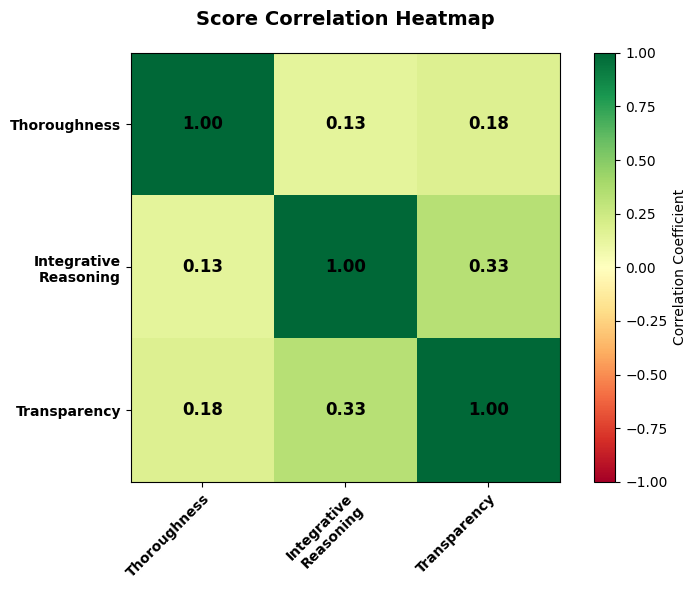


📊 Interpretation:
Strong positive correlation (>0.7) indicates metrics tend to move together.
This suggests consistent case quality across different evaluation dimensions.

✅ Pass Count: 390 / 429 (90.9%)
❌ Fail Count: 39 / 429 (9.1%)


In [8]:
# Comparative Analysis: Score Correlation Heatmap
import matplotlib.pyplot as plt
import numpy as np

# Extract scores for correlation analysis
scores_data = {
    'Thoroughness': [m.get('scores', {}).get('thoroughness', 0) for m in quality_metrics],
    'Integrative': [m.get('scores', {}).get('integrative_reasoning', 0) for m in quality_metrics],
    'Transparency': [m.get('scores', {}).get('transparency', 0) for m in quality_metrics]
}

# Calculate correlation matrix
correlation_matrix = np.corrcoef([scores_data['Thoroughness'],
                                   scores_data['Integrative'],
                                   scores_data['Transparency']])

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap='RdYlGn', vmin=-1, vmax=1)

# Set labels
labels = ['Thoroughness', 'Integrative\nReasoning', 'Transparency']
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontweight='bold')
ax.set_yticklabels(labels, fontweight='bold')

# Rotate the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add correlation values in cells
for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f'{correlation_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontweight='bold', fontsize=12)

ax.set_title('Score Correlation Heatmap', fontweight='bold', fontsize=14, pad=20)
fig.colorbar(im, ax=ax, label='Correlation Coefficient')
plt.tight_layout()
plt.show()

# Count pass/fail
passed_count = sum(1 for m in quality_metrics if m.get('status') == 'KEEP')
failed_count = len(quality_metrics) - passed_count
pass_rate = (passed_count / len(quality_metrics) * 100) if quality_metrics else 0

print("\n📊 Interpretation:")
print("Strong positive correlation (>0.7) indicates metrics tend to move together.")
print("This suggests consistent case quality across different evaluation dimensions.")
print(f"\n✅ Pass Count: {passed_count} / {len(quality_metrics)} ({pass_rate:.1f}%)")
print(f"❌ Fail Count: {failed_count} / {len(quality_metrics)} ({100-pass_rate:.1f}%)")

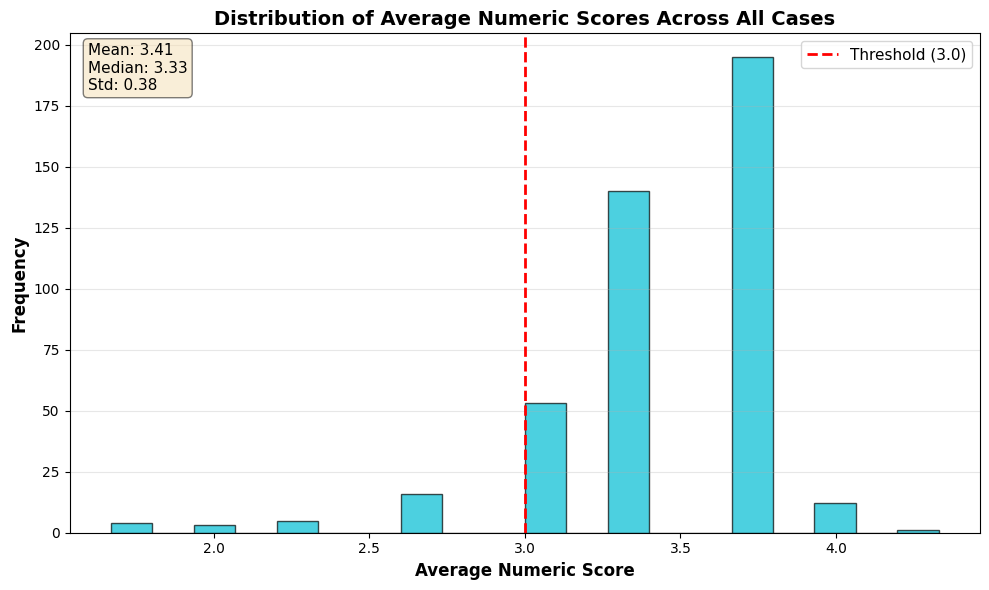

In [9]:
# Additional Analysis: Average Numeric Score Distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

avg_numeric_scores = [m.get('average_numeric_score', 0) for m in quality_metrics if m.get('average_numeric_score')]
ax.hist(avg_numeric_scores, bins=20, color='#00BCD4', edgecolor='black', alpha=0.7)
ax.axvline(x=3.0, color='red', linestyle='--', linewidth=2, label='Threshold (3.0)')
ax.set_xlabel('Average Numeric Score', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax.set_title('Distribution of Average Numeric Scores Across All Cases', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add statistics text box
textstr = f'Mean: {np.mean(avg_numeric_scores):.2f}\nMedian: {np.median(avg_numeric_scores):.2f}\nStd: {np.std(avg_numeric_scores):.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

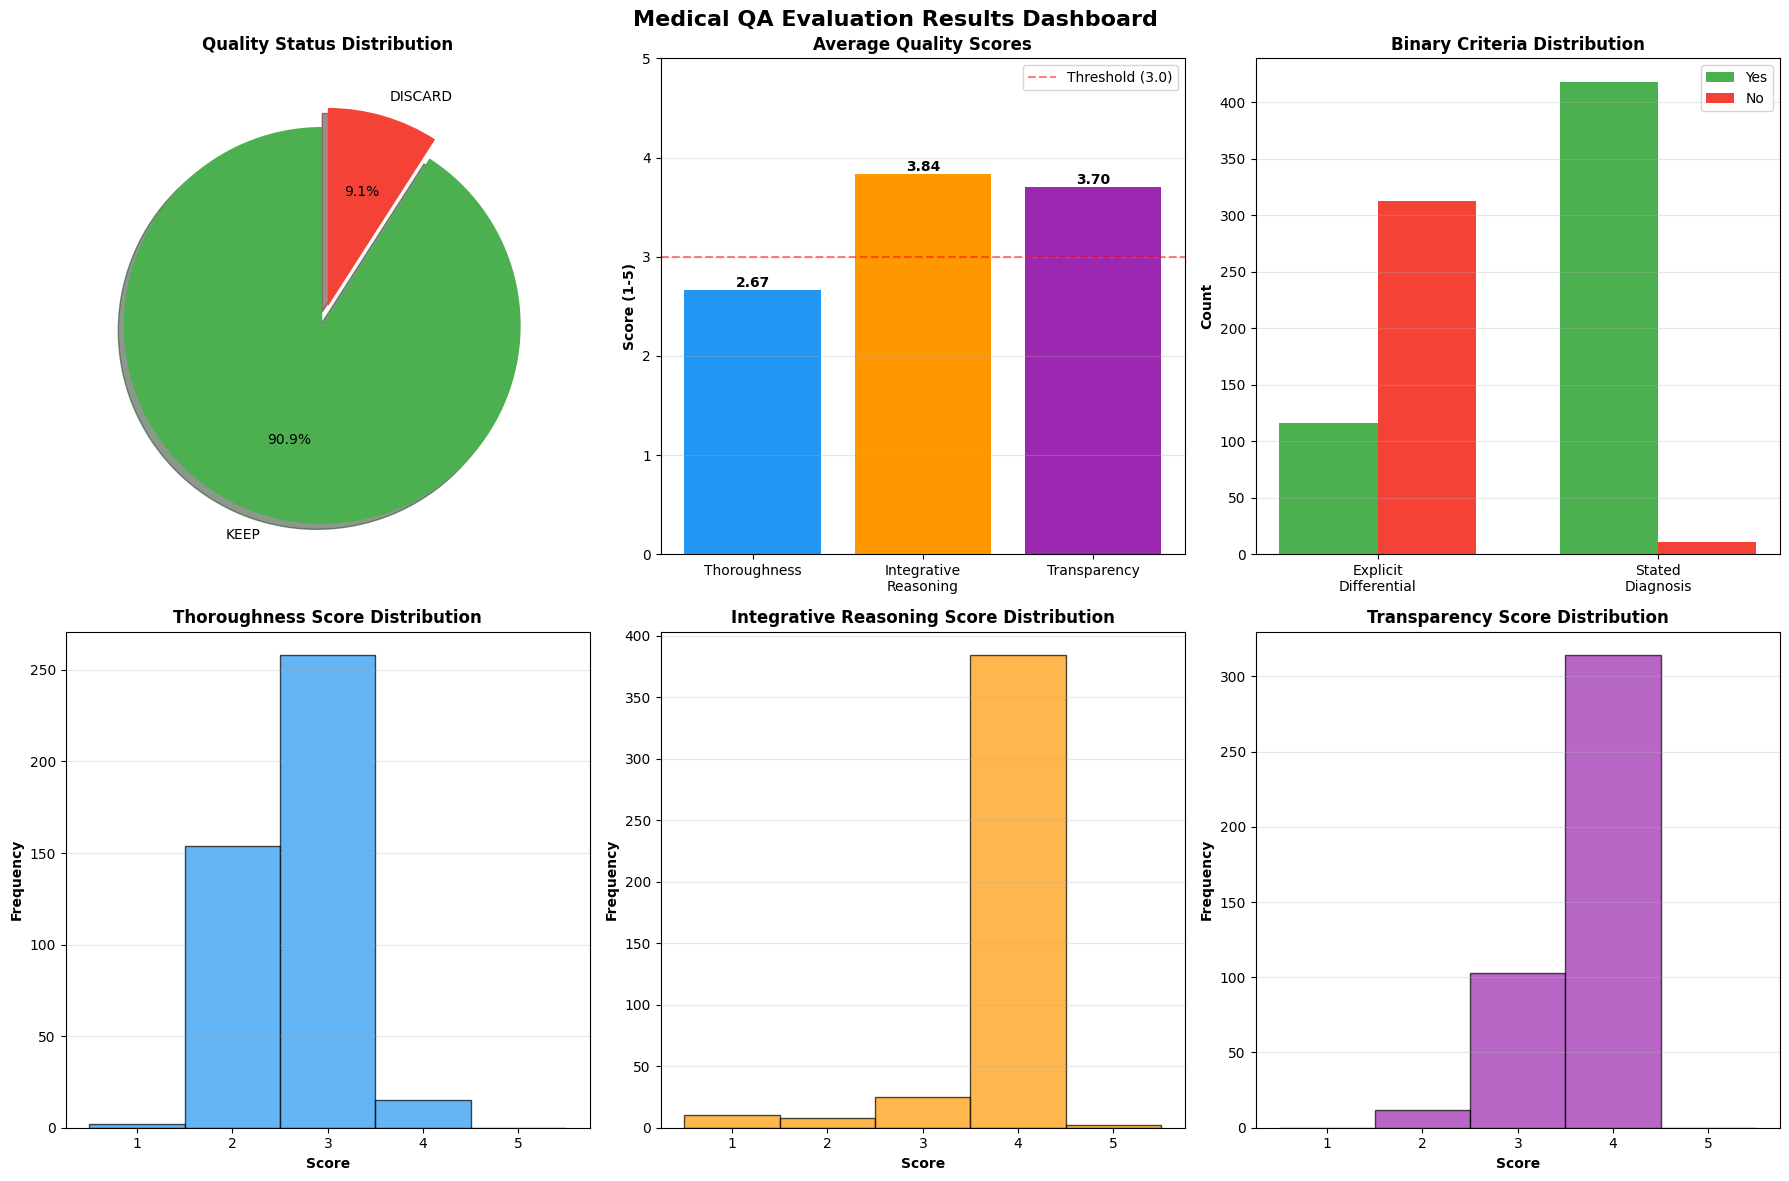

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Medical QA Evaluation Results Dashboard', fontsize=16, fontweight='bold')

# 1. KEEP vs DISCARD Pie Chart
ax1 = axes[0, 0]
labels = ['KEEP', 'DISCARD']
sizes = [keep_count, discard_count]
colors = ['#4CAF50', '#F44336']
explode = (0.1, 0)
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.set_title('Quality Status Distribution', fontweight='bold')

# 2. Average Scores Bar Chart
ax2 = axes[0, 1]
metrics = ['Thoroughness', 'Integrative\nReasoning', 'Transparency']
scores = [avg_thoroughness, avg_integrative, avg_transparency]
bars = ax2.bar(metrics, scores, color=['#2196F3', '#FF9800', '#9C27B0'])
ax2.set_ylim(0, 5)
ax2.set_ylabel('Score (1-5)', fontweight='bold')
ax2.set_title('Average Quality Scores', fontweight='bold')
ax2.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Threshold (3.0)')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Binary Criteria (Yes/No)
ax3 = axes[0, 2]
criteria = ['Explicit\nDifferential', 'Stated\nDiagnosis']
yes_counts = [differential_yes, diagnosis_stated_yes]
no_counts = [len(quality_metrics) - differential_yes, len(quality_metrics) - diagnosis_stated_yes]
x = np.arange(len(criteria))
width = 0.35
ax3.bar(x - width/2, yes_counts, width, label='Yes', color='#4CAF50')
ax3.bar(x + width/2, no_counts, width, label='No', color='#F44336')
ax3.set_ylabel('Count', fontweight='bold')
ax3.set_title('Binary Criteria Distribution', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(criteria)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Score Distribution Histogram - Thoroughness
ax4 = axes[1, 0]
thoroughness_scores = [m.get('scores', {}).get('thoroughness', 0) for m in quality_metrics]
ax4.hist(thoroughness_scores, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
         color='#2196F3', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Score', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Thoroughness Score Distribution', fontweight='bold')
ax4.set_xticks([1, 2, 3, 4, 5])
ax4.grid(axis='y', alpha=0.3)

# 5. Score Distribution Histogram - Integrative Reasoning
ax5 = axes[1, 1]
integrative_scores = [m.get('scores', {}).get('integrative_reasoning', 0) for m in quality_metrics]
ax5.hist(integrative_scores, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
         color='#FF9800', edgecolor='black', alpha=0.7)
ax5.set_xlabel('Score', fontweight='bold')
ax5.set_ylabel('Frequency', fontweight='bold')
ax5.set_title('Integrative Reasoning Score Distribution', fontweight='bold')
ax5.set_xticks([1, 2, 3, 4, 5])
ax5.grid(axis='y', alpha=0.3)

# 6. Score Distribution Histogram - Transparency
ax6 = axes[1, 2]
transparency_scores = [m.get('scores', {}).get('transparency', 0) for m in quality_metrics]
ax6.hist(transparency_scores, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
         color='#9C27B0', edgecolor='black', alpha=0.7)
ax6.set_xlabel('Score', fontweight='bold')
ax6.set_ylabel('Frequency', fontweight='bold')
ax6.set_title('Transparency Score Distribution', fontweight='bold')
ax6.set_xticks([1, 2, 3, 4, 5])
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()